# <center> <font color="#004C46">Maestria en Inteligencia Artificial Aplicada (MNA)</font> </center>

<center>

[![Institucion](https://img.shields.io/badge/INSTITUCI%C3%93N-TECNOL%C3%93GICO_DE_MONTERREY-003A70?style=for-the-badge)](https://tec.mx)
[![Programa](https://img.shields.io/badge/PROGRAMA-MNA-004C46?style=for-the-badge)](https://tec.mx)
[![Materia](https://img.shields.io/badge/MATERIA-PROYECTO_INTEGRADOR-1255C?style=for-the-badge)](https://tec.mx)

</center>

<center>

[![Python](https://img.shields.io/badge/Python-3776AB?style=flat-square&logo=python&logoColor=white)](https://www.python.org/)
[![Jupyter](https://img.shields.io/badge/Jupyter-F37626?style=flat-square&logo=jupyter&logoColor=white)](https://jupyter.org/)
[![Prophet](https://img.shields.io/badge/Prophet-3B5998?style=flat-square&logo=meta&logoColor=white)](https://facebook.github.io/prophet/)
[![DeepAR](https://img.shields.io/badge/DeepAR-FF9900?style=flat-square&logo=amazonaws&logoColor=white)](https://ts.gluon.ai/)
[![XGBoost](https://img.shields.io/badge/XGBoost-017A3A?style=flat-square)](https://xgboost.readthedocs.io/)
[![GitHub](https://img.shields.io/badge/Repo-GitHub-181717?style=flat-square&logo=github&logoColor=white)](https://github.com/IntegradorIMSS2026Team01/EpiForecast-MX)

</center>

---

## **<font color="#004C46">Semana 7: Avance 5 — Modelo Final (Ensemble Learning)</font>**

### **<font color="#7B2132">Proyecto: EpiForecast-MX</font>**

**Materia:** Proyecto Integrador — TC5035.10

> **Titulo:** Generalizacion de modelos nacionales de pronostico epidemiologico hacia un enfoque modular con desagregacion por sexo y entidad federativa en Mexico.

---

### **Objetivos de esta entrega**

**Objetivo 3.5** — Implementar al menos 4 modelos de ensemble learning (homogeneo y heterogeneo) utilizando los mejores modelos individuales como base para stacking/blending.

**Objetivo 3.6** — Comparar y evaluar todos los modelos entrenados con una tabla comparativa ordenada por la metrica principal (MASE), acompanada de al menos 2 metricas adicionales, tiempos de entrenamiento y argumentos solidos para la seleccion del modelo final.

---

### **Cuerpo Docente y Patrocinio**

* **Dra. Grettel Barcelo Alonso** | Profesora Titular y Asesora
* **Dra. Ruth Perez-Hernandez** | Lider del Proyecto IMSS
* **Dra. Lina Diaz Castro** | Investigadora en Psiquiatria IMSS

---

## **<center> <font color="#004C46">Equipo de Desarrollo #1</font> </center>**

<table style="width:100%; border:none; border-collapse:collapse;">
<tr>
    <td align="center" style="border:none; width:33%; padding:10px;">
<img src="https://proyectointegrador.org/JARS20206.jpg" width="140px" style="border-radius:10px;">
<br><h4>Javier Augusto Rebull Saucedo</h4><code>A01795838</code><br>
<small>MNA Student &middot; Sr. Associate Dev — Santander</small>
    </td>
    <td align="center" style="border:none; width:33%; padding:10px;">
<img src="https://proyectointegrador.org/JARCOS2026.png" width="140px" style="border-radius:10px;">
<br><h4>Juan Carlos Perez Nava</h4><code>A01795941</code><br>
<small>MNA Student &middot; IT Professional — IMSS</small>
    </td>
    <td align="center" style="border:none; width:33%; padding:10px;">
<img src="https://proyectointegrador.org/LUIS2026.jpg" width="140px" style="border-radius:10px;">
<br><h4>Luis Gerardo Sanchez Salazar</h4><code>A01232963</code><br>
<small>MNA Student &middot; Sr. Controls Engineer — Tesla</small>
    </td>
</tr>
</table>

**Fecha de entrega:** Marzo 2026

---

In [1]:
# Cell 1 — Imports y configuracion global
from __future__ import annotations

from dataclasses import dataclass, field
import os
from pathlib import Path
import pickle
import shutil
import warnings

import matplotlib.dates as mdates
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# Cambiar CWD a la raiz del repositorio para que pickle.load()
# pueda resolver imports de epiforecast.utils.config
os.chdir(Path("..").resolve())

sns.set_theme(
    style="whitegrid",
    font_scale=1.1,
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 150,
        "savefig.dpi": 200,
        "font.family": "sans-serif",
    },
)


@dataclass(frozen=True)
class NotebookConfig:
    repo: Path = Path()
    fig_dir: Path = Path("notebooks/figuras_avance5")

    @property
    def excel_metricas(self) -> Path:
        return self.repo / "reports/forecasts/comparacion_modelos/comparacion_metricas.xlsx"

    @property
    def models_dir(self) -> Path:
        return self.repo / "models"

    @property
    def forecasts_dir(self) -> Path:
        return self.repo / "reports/forecasts"

    padecimientos: tuple[str, ...] = ("Alzheimer", "Depresion", "Parkinson")
    pad_display: dict[str, str] = field(
        default_factory=lambda: {
            "Alzheimer": "Alzheimer (G30)",
            "Depresion": "Depresion (F32)",
            "Parkinson": "Parkinson (G20)",
        }
    )
    modelos: tuple[str, ...] = ("Prophet", "DeepAR", "Ensemble", "Stacking")
    model_prefixes: dict[str, str] = field(
        default_factory=lambda: {
            "Prophet": "Prophet",
            "DeepAR": "Deepar",
            "Ensemble": "Ensemble",
            "Stacking": "Stacking",
        }
    )
    color_imss_verde: str = "#004C46"
    color_imss_rojo: str = "#7B2132"
    colores_modelo: dict[str, str] = field(
        default_factory=lambda: {
            "Prophet": "#2E7D32",
            "DeepAR": "#6A1B9A",
            "Ensemble": "#E65100",
            "Stacking": "#1A237E",
        }
    )
    color_real: str = "#2C2C2C"
    color_gold: str = "#DAA520"


cfg = NotebookConfig()
cfg.fig_dir.mkdir(parents=True, exist_ok=True)


def guardar(fig: plt.Figure, nombre: str) -> None:
    path = cfg.fig_dir / f"{nombre}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight", facecolor="white")
    print(f"  Guardado: {path}")


print(f"Configuracion cargada. Repo: {cfg.repo.resolve()}")
print(f"CWD: {Path.cwd()}")

Configuracion cargada. Repo: /Users/haowei/Documents/Integrador/EpiForecast-MX
CWD: /Users/haowei/Documents/Integrador/EpiForecast-MX


In [2]:
# Cell 2 — Carga de datos (MetricsLoader)
class MetricsLoader:
    def __init__(self, config: NotebookConfig) -> None:
        self.cfg = config
        self.resumen: pd.DataFrame = pd.DataFrame()
        self.detalle: pd.DataFrame = pd.DataFrame()
        self.completos: dict[str, pd.DataFrame] = {}
        self.forecasts_nac: dict[str, dict[str, pd.DataFrame]] = {}

    def load_all(self) -> MetricsLoader:
        self._load_excel()
        self._load_completos()
        self._load_forecasts_nacionales()
        self._print_summary()
        return self

    def _load_excel(self) -> None:
        xl = self.cfg.excel_metricas
        assert xl.exists(), f"No existe: {xl}"
        self.resumen = pd.read_excel(xl, sheet_name="Resumen")
        self.detalle = pd.read_excel(xl, sheet_name="Detalle")
        print(f"Excel cargado: Resumen {self.resumen.shape}, Detalle {self.detalle.shape}")

    def _load_completos(self) -> None:
        for modelo in self.cfg.modelos:
            prefix = self.cfg.model_prefixes[modelo]
            for pad in self.cfg.padecimientos:
                key = f"{modelo}_{pad}"
                path = self.cfg.models_dir / modelo.lower() / pad / f"{prefix}_{pad}_completo.csv"
                if path.exists():
                    self.completos[key] = pd.read_csv(path)
                else:
                    print(f"  AVISO: no existe {path.name}")
        print(f"Completos cargados: {len(self.completos)} de 12")

    def _load_forecasts_nacionales(self) -> None:
        for modelo in self.cfg.modelos:
            csv_path = (
                self.cfg.forecasts_dir / modelo.lower() / f"all_forecast_{modelo.lower()}.csv"
            )
            if not csv_path.exists():
                continue
            df = pd.read_csv(csv_path, low_memory=False)
            df["ds"] = pd.to_datetime(df["ds"])
            self.forecasts_nac[modelo] = {}
            for pad in self.cfg.padecimientos:
                mask = (
                    df["meta_padecimiento"].str.contains(pad[:5], case=False, na=False)
                    & (df["meta_entidad"] == "Nacional")
                    & (df["meta_modo"] == "general")
                )
                sub = df[mask].copy()
                if not sub.empty:
                    self.forecasts_nac[modelo][pad] = sub
        print(f"Forecasts nacionales: {len(self.forecasts_nac)} modelos")

    def load_serie_real(self, pad: str) -> pd.DataFrame:
        for model_key in ["prophet", "ensemble", "stacking", "deepar"]:
            prefix = {
                "prophet": "Prophet",
                "ensemble": "Ensemble",
                "stacking": "Stacking",
                "deepar": "Deepar",
            }[model_key]
            path = self.cfg.models_dir / model_key / pad / f"{prefix}_{pad}_general.csv"
            if path.exists():
                df = pd.read_csv(path)
                df["ds"] = pd.to_datetime(df["ds"])
                return df
        raise FileNotFoundError(f"No se encontro serie real para {pad}")

    def _print_summary(self) -> None:
        print("\n--- Resumen de carga ---")
        print(
            f"  Detalle: {self.detalle.shape[0]} filas | Completos: {len(self.completos)} | Forecasts: {sum(len(v) for v in self.forecasts_nac.values())} series"
        )


loader = MetricsLoader(cfg).load_all()

Excel cargado: Resumen (3, 26), Detalle (441, 37)
Completos cargados: 12 de 12


Forecasts nacionales: 4 modelos

--- Resumen de carga ---
  Detalle: 441 filas | Completos: 12 | Forecasts: 12 series


---

## **<font color="#004C46">1. Marco Teorico: Ensemble Learning en Series de Tiempo Epidemiologicas</font>**

El aprendizaje por ensamble (*ensemble learning*) combina las predicciones de multiples modelos base para producir un pronostico mas robusto y generalizable que cualquier modelo individual. En el contexto de series de tiempo epidemiologicas, donde la incidencia semanal presenta estacionalidad anual, cambios de regimen post-COVID y alta variabilidad entre entidades federativas, la diversificacion de algoritmos resulta especialmente valiosa.

EpiForecast-MX implementa cuatro motores de pronostico que abarcan el espectro completo de estrategias de ensamble:

| Motor | Categoria | Estrategia | Modelos base | Meta-learner |
|:------|:----------|:-----------|:-------------|:-------------|
| **Prophet** | Individual (baseline) | Modelo aditivo bayesiano con estacionalidad Fourier | — | — |
| **DeepAR** | Homogeneo (multi-serie) | LSTM autoregresiva probabilistica, 32 series simultaneas | — | — |
| **Ensemble** | Heterogeneo (promedio ponderado) | Prophet + XGBoost con 15 features; pesos OOF via Ridge | Prophet + XGBoost | Ridge (no negativo) |
| **Stacking** | Heterogeneo (stacking generalizado) | 3 expertos independientes; ElasticNet como meta-learner | Prophet + ETS + LightGBM | ElasticNet |

La metrica primaria de evaluacion es **MASE** (Mean Absolute Scaled Error, Hyndman y Koehler 2006), que compara el error absoluto del modelo contra un *naive seasonal* de periodo 52 semanas. Un MASE < 1.0 indica que el modelo supera al predictor trivial. Se prefiere sobre MAPE porque no se infla con series de baja incidencia (Alzheimer en estados pequenos puede registrar 0-2 casos/semana, donde MAPE diverge a infinito). Como metrica secundaria se utiliza **SMAPE** y **RMSE** para capturar la magnitud absoluta del error.

*Referencias: Singh (2023), VanderPlas (2022), Hyndman & Koehler (2006).*

---

## **<font color="#004C46">2. Arquitectura de 333 Modelos por Motor</font>**

In [3]:
# Cell 4 — Tabla de 333 modelos
data_333 = {
    "Nivel": [
        "Estatal (32 entidades)",
        "Nacional",
        "Regional (4 regiones INEGI)",
        "Subtotal por padecimiento",
        "TOTAL por motor (3 pad.)",
        "TOTAL proyecto (4 motores)",
    ],
    "Sexos": ["x 3 (H, M, Comb.)", "x 3", "x 3", "", "", ""],
    "Series": ["96", "3", "12", "111", "333", "1,332 modelos"],
    "Artefactos": [
        "96 .pkl + 96 .csv",
        "3 .pkl + 3 .csv",
        "12 .pkl + 12 .csv",
        "111 .pkl + 112 .csv",
        "333 .pkl + ~339 .csv",
        "2,685 archivos",
    ],
}
df_333 = pd.DataFrame(data_333)
display(
    df_333.style.set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("background-color", "#004C46"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                ],
            },
            {"selector": "td", "props": [("border", "1px solid #ddd"), ("padding", "6px")]},
        ]
    )
    .hide(axis="index")
    .set_caption("Composicion de los 333 modelos por motor de pronostico")
)

Nivel,Sexos,Series,Artefactos
Estatal (32 entidades),"x 3 (H, M, Comb.)",96,96 .pkl + 96 .csv
Nacional,x 3,3,3 .pkl + 3 .csv
Regional (4 regiones INEGI),x 3,12,12 .pkl + 12 .csv
Subtotal por padecimiento,,111,111 .pkl + 112 .csv
TOTAL por motor (3 pad.),,333,333 .pkl + ~339 .csv
TOTAL proyecto (4 motores),,"1,332 modelos","2,685 archivos"


---

## **<font color="#004C46">3. Fichas Tecnicas de los 4 Motores</font>**

In [ ]:
# Cell 5 — Fichas tecnicas con datos reales de los pkl y Excel
tiempos = {}
for modelo in cfg.modelos:
    col = f"Tiempo (s) {modelo}"
    tiempos[modelo] = (
        loader.detalle[col].sum() / 60 if col in loader.detalle.columns else float("nan")
    )


def _load_params(modelo: str, pad: str = "Depresion") -> dict:
    prefix = cfg.model_prefixes[modelo]
    path = cfg.models_dir / modelo.lower() / pad / f"{prefix}_{pad}_general.pkl"
    if not path.exists():
        return {}
    try:
        with path.open("rb") as f:
            data = pickle.load(f)
        return data.get("params", {})
    except Exception:
        return {}


fichas = []
for modelo in cfg.modelos:
    p = _load_params(modelo)
    t = f"{tiempos[modelo]:.1f} min" if not np.isnan(tiempos[modelo]) else "N/D"
    if modelo == "Prophet":
        hp = p.get("prophet", p)
        fichas.append(
            {
                "Motor": modelo,
                "Categoria": "Individual (baseline)",
                "Base": "Aditivo bayesiano",
                "Meta-learner": "\u2014",
                "HP clave": f"cps={hp.get('changepoint_prior_scale', '?')}, sp={hp.get('seasonality_prior_scale', '?')}",
                "Tiempo": t,
            }
        )
    elif modelo == "DeepAR":
        fichas.append(
            {
                "Motor": modelo,
                "Categoria": "Homogeneo (multi-serie)",
                "Base": "LSTM autoregresiva (GluonTS+PyTorch)",
                "Meta-learner": "\u2014",
                "HP clave": "context=52, horizon=52, epochs=100",
                "Tiempo": t,
            }
        )
    elif modelo == "Ensemble":
        xgb_hp = p.get("xgboost", {})
        fichas.append(
            {
                "Motor": "Ensemble Paralelo",
                "Categoria": "Heterogeneo (prom. ponderado)",
                "Base": "Prophet + XGBoost (15 features)",
                "Meta-learner": "Ridge (OOF, no negativo)",
                "HP clave": f"n_est={xgb_hp.get('n_estimators', '?')}, depth={xgb_hp.get('max_depth', '?')}, lr={xgb_hp.get('learning_rate', '?')}",
                "Tiempo": t,
            }
        )
    else:
        fichas.append(
            {
                "Motor": "Stacking Generalizado",
                "Categoria": "Heterogeneo (stacking)",
                "Base": "Prophet + ETS + LightGBM",
                "Meta-learner": f"ElasticNet (alpha={p.get('alpha', 0.1)})",
                "HP clave": f"horizon={p.get('horizon', 52)} sem, folds=3",
                "Tiempo": t,
            }
        )

df_fichas = pd.DataFrame(fichas).set_index("Motor").T
display(
    df_fichas.style.set_properties(**{"text-align": "left", "font-size": "11px"})
    .set_table_styles(
        [{"selector": "th", "props": [("background-color", "#004C46"), ("color", "white")]}]
    )
    .set_caption("Tabla 1. Fichas tecnicas de los 4 motores de pronostico")
)

---

## **<font color="#004C46">4. Series de Tiempo: Real vs 4 Modelos (Nacional)</font>**

Curvas de pronostico nacional (modo combinado) para cada padecimiento, superponiendo los 4 motores sobre la serie real historica. El area sombreada representa el intervalo de confianza al 80%. La linea vertical punteada marca el inicio del periodo de prueba (enero 2025). Cada grafico incluye un recuadro ampliado del periodo de prueba.

  Guardado: notebooks/figuras_avance5/06_pronostico_nacional_alzheimer.png


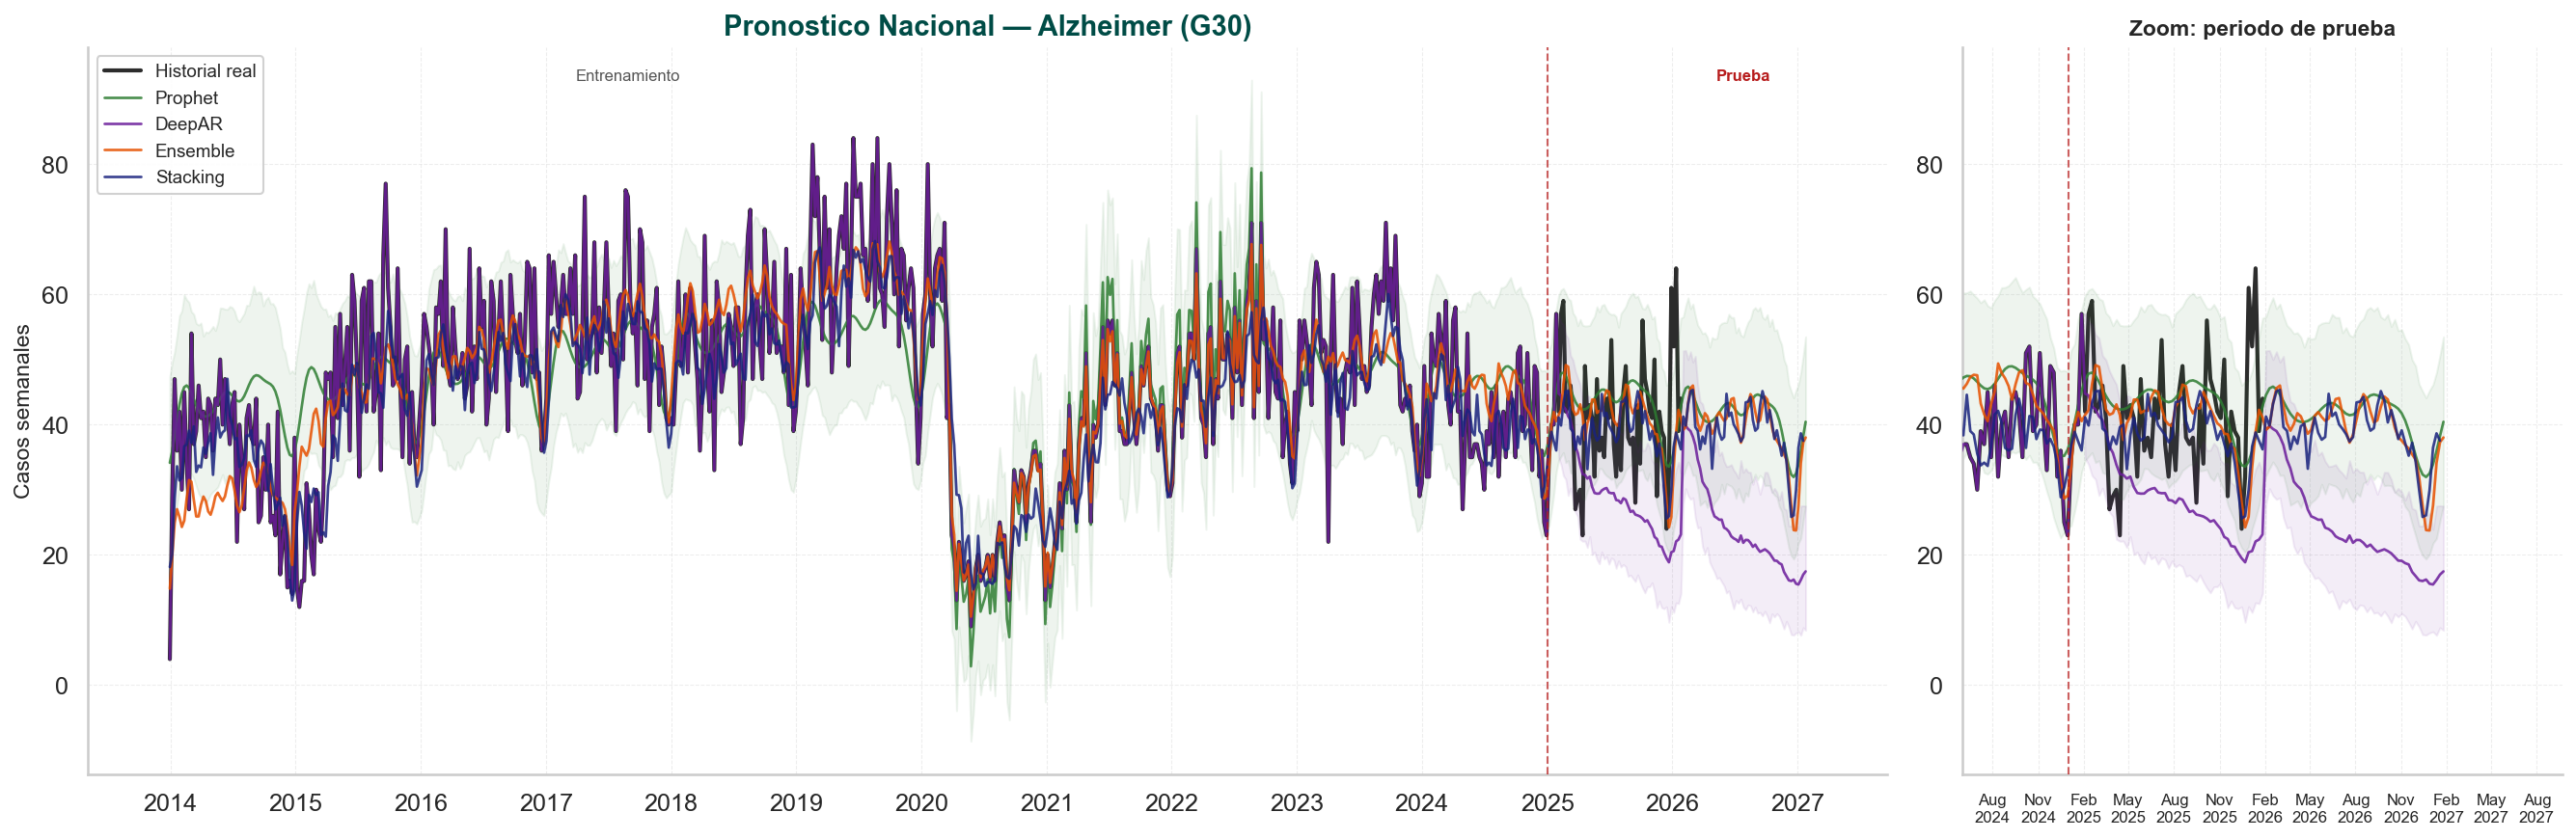

  Guardado: notebooks/figuras_avance5/06_pronostico_nacional_depresion.png


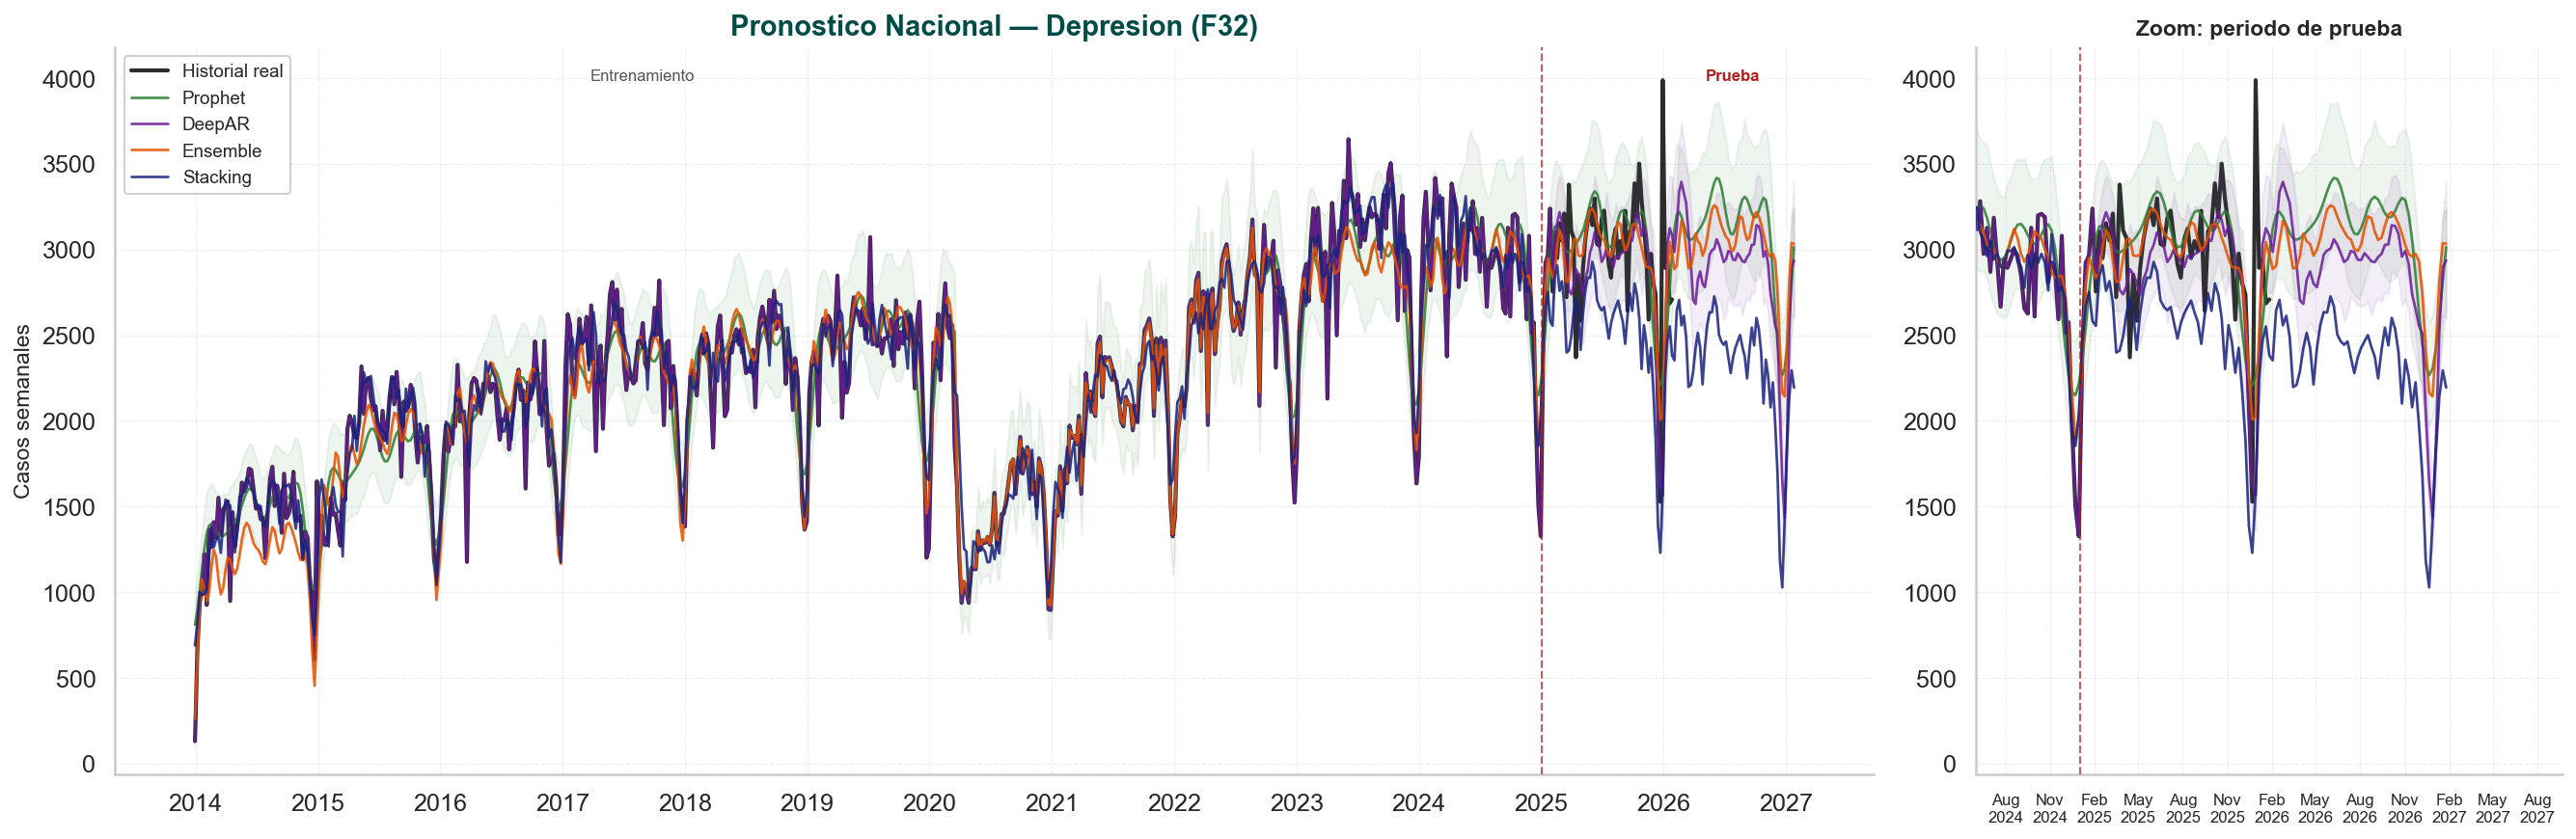

  Guardado: notebooks/figuras_avance5/06_pronostico_nacional_parkinson.png


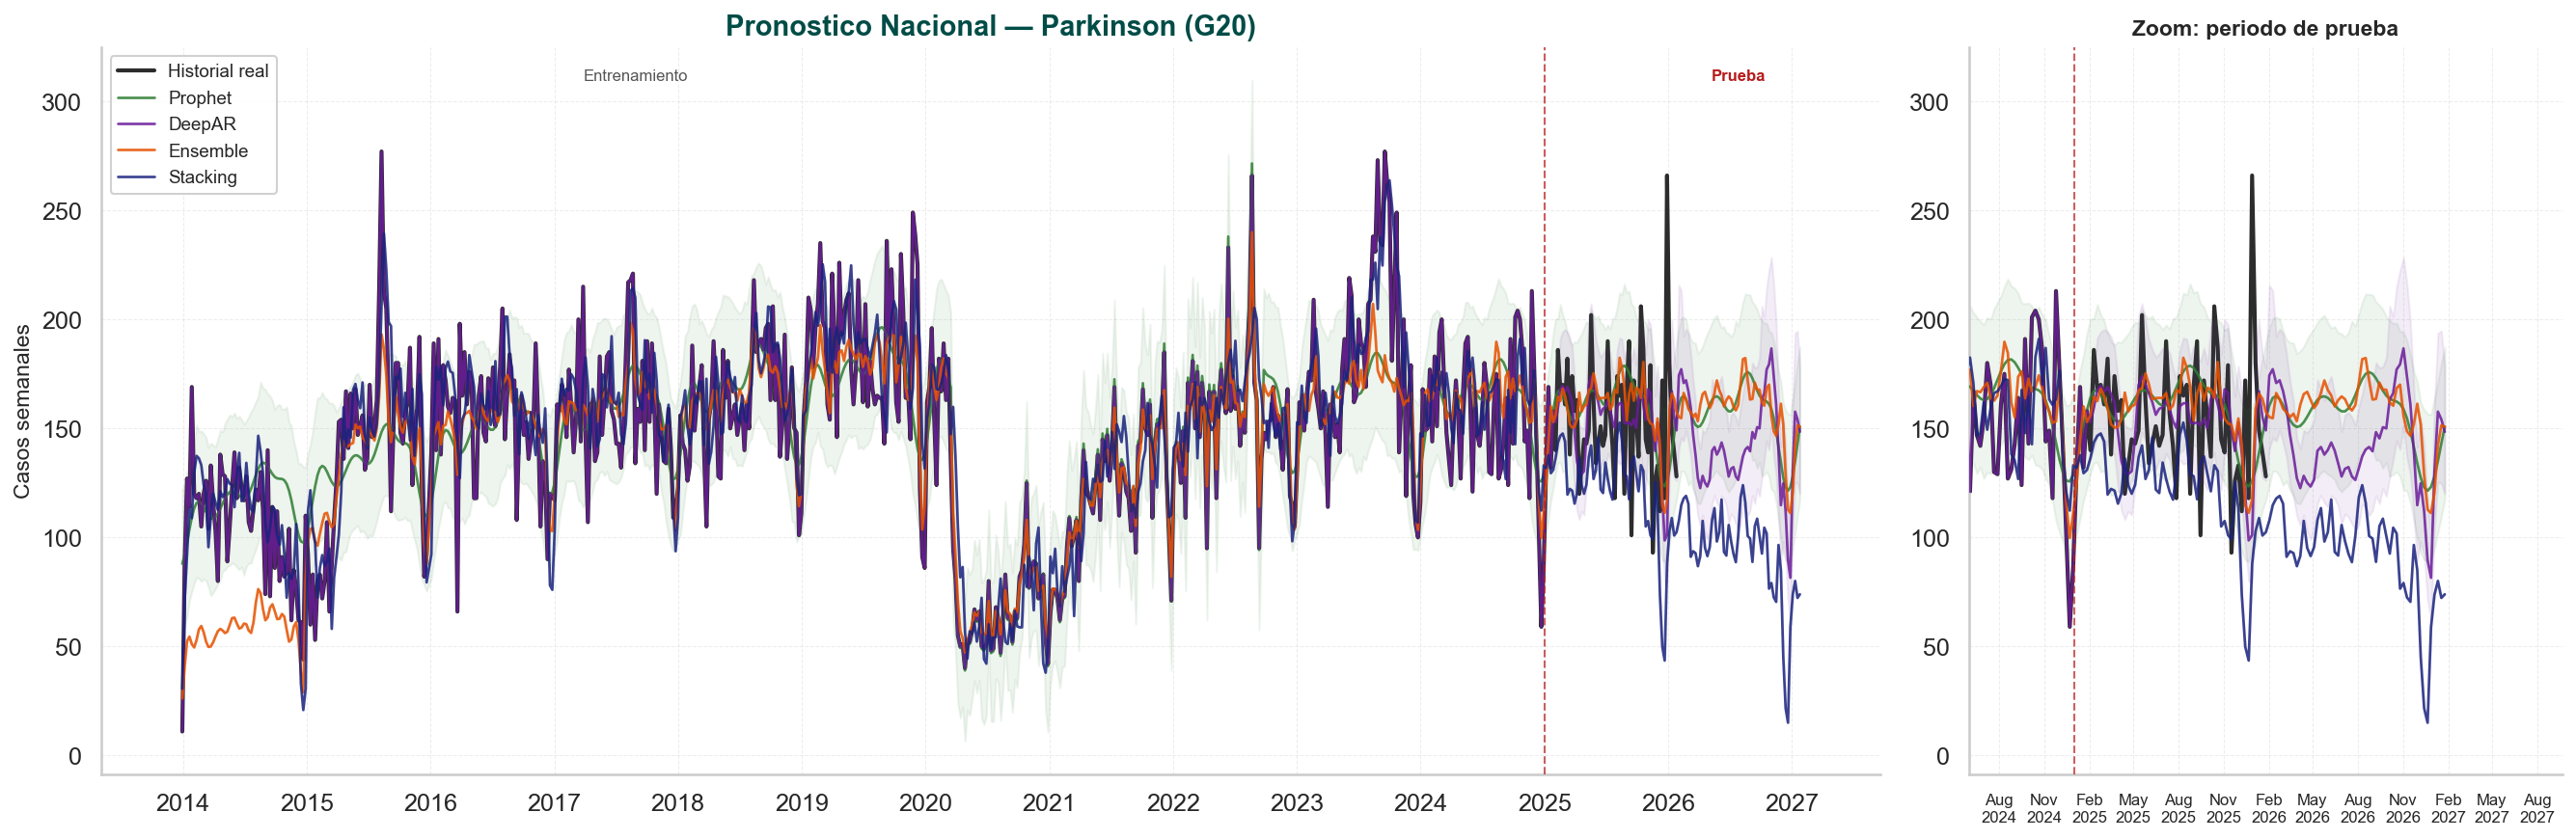

In [5]:
# Cell 6 — Pronostico Nacional con 4 modelos + zoom
for pad in cfg.padecimientos:
    serie = loader.load_serie_real(pad)
    y_col = "y_original" if "y_original" in serie.columns else "y"
    ds_real, y_real = serie["ds"], serie[y_col]

    fig, (ax_main, ax_zoom) = plt.subplots(
        1, 2, figsize=(18, 6), gridspec_kw={"width_ratios": [3, 1]}
    )
    cutoff = pd.Timestamp("2025-01-01")

    for ax in (ax_main, ax_zoom):
        ax.plot(
            ds_real, y_real, color=cfg.color_real, linewidth=2.0, label="Historial real", zorder=1
        )
        for modelo in cfg.modelos:
            if modelo not in loader.forecasts_nac or pad not in loader.forecasts_nac.get(
                modelo, {}
            ):
                continue
            fc = loader.forecasts_nac[modelo][pad]
            color = cfg.colores_modelo[modelo]
            ax.plot(
                fc["ds"],
                fc["yhat"],
                color=color,
                linewidth=1.3,
                label=modelo,
                alpha=0.85,
                zorder=3,
            )
            if "yhat_lower" in fc.columns and "yhat_upper" in fc.columns:
                ax.fill_between(
                    fc["ds"], fc["yhat_lower"], fc["yhat_upper"], color=color, alpha=0.08
                )
        ax.axvline(cutoff, color="#B71C1C", linestyle="--", linewidth=1, alpha=0.7, zorder=5)
        ax.grid(True, color="lightgrey", linestyle="--", linewidth=0.5, alpha=0.4)

    ax_main.set_title(
        f"Pronostico Nacional — {cfg.pad_display[pad]}",
        fontsize=14,
        fontweight="bold",
        color=cfg.color_imss_verde,
    )
    ax_main.set_ylabel("Casos semanales", fontsize=11)
    ax_main.xaxis.set_major_locator(mdates.YearLocator())
    ax_main.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax_main.legend(fontsize=9, loc="upper left", framealpha=0.9)
    ax_main.annotate(
        "Entrenamiento",
        xy=(0.3, 0.97),
        xycoords="axes fraction",
        fontsize=8,
        color="#555",
        ha="center",
        va="top",
    )
    ax_main.annotate(
        "Prueba",
        xy=(0.92, 0.97),
        xycoords="axes fraction",
        fontsize=8,
        color="#B71C1C",
        ha="center",
        va="top",
        fontweight="bold",
    )

    ax_zoom.set_xlim(pd.Timestamp("2024-06-01"), None)
    ax_zoom.set_title("Zoom: periodo de prueba", fontsize=11, fontweight="bold")
    ax_zoom.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax_zoom.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    ax_zoom.tick_params(axis="x", labelsize=8)

    fig.tight_layout()
    guardar(fig, f"06_pronostico_nacional_{pad.lower()}")
    plt.show()
    plt.close(fig)

---

## **<font color="#004C46">5. Analisis de Residuales (Modelo Ensemble — Nacional)</font>**

  Guardado: notebooks/figuras_avance5/07_residuales_alzheimer.png


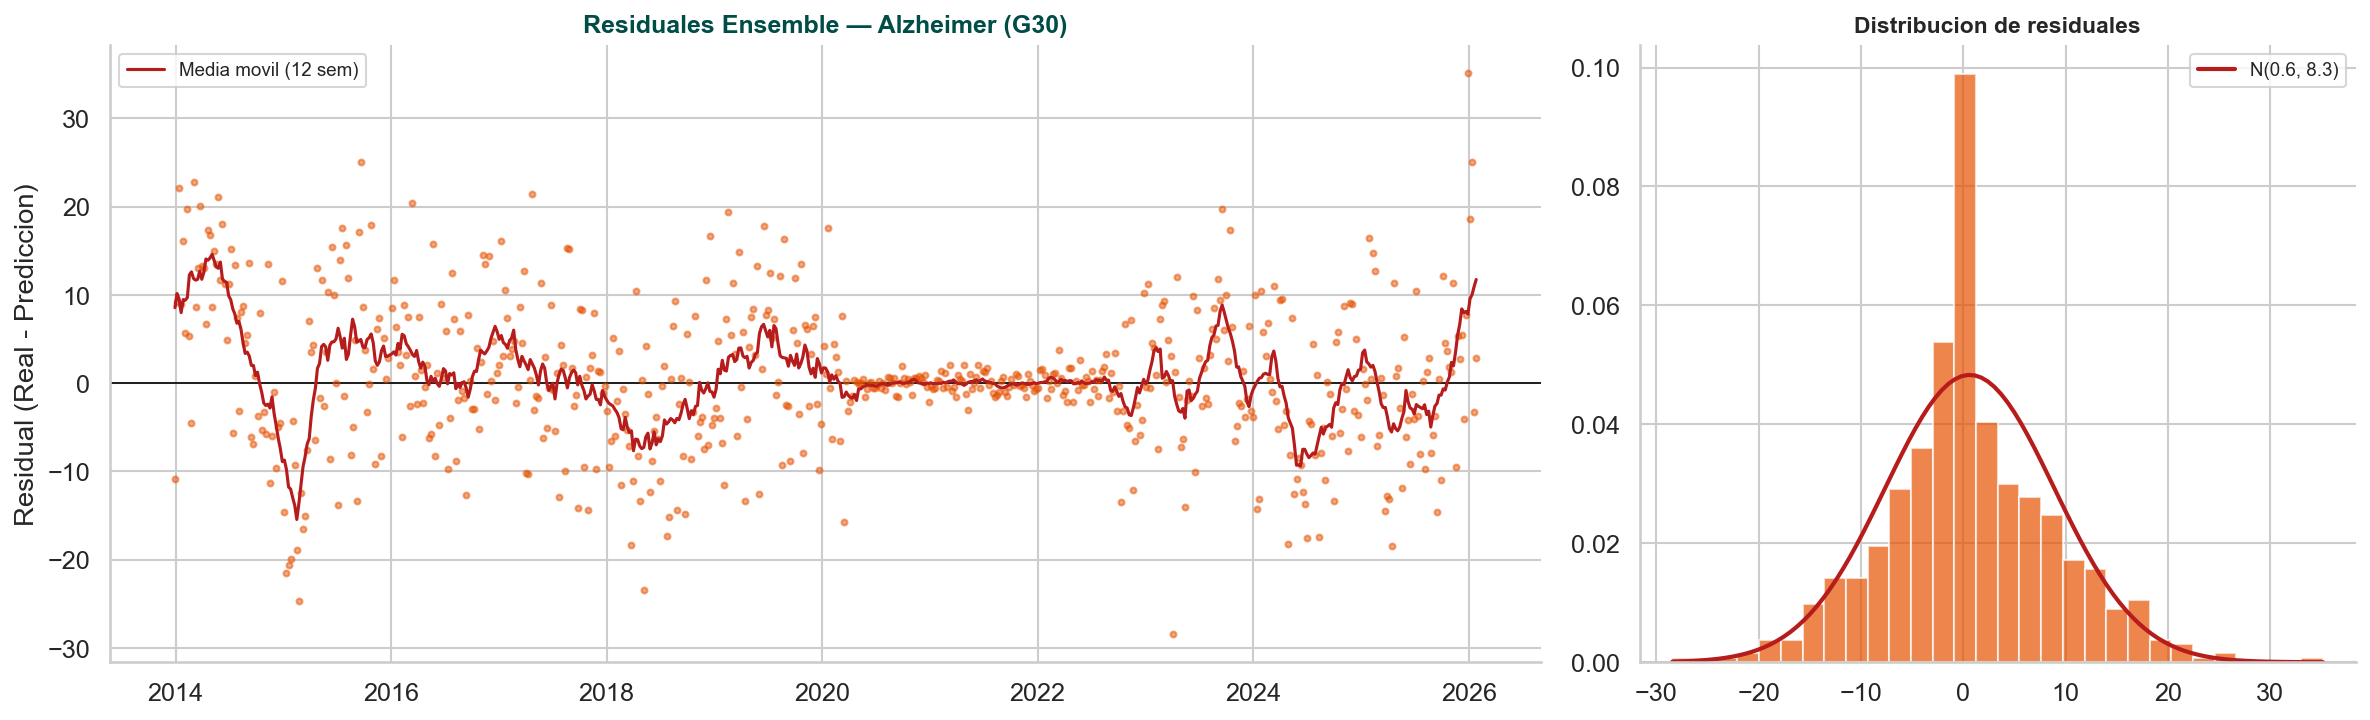

  Guardado: notebooks/figuras_avance5/07_residuales_depresion.png

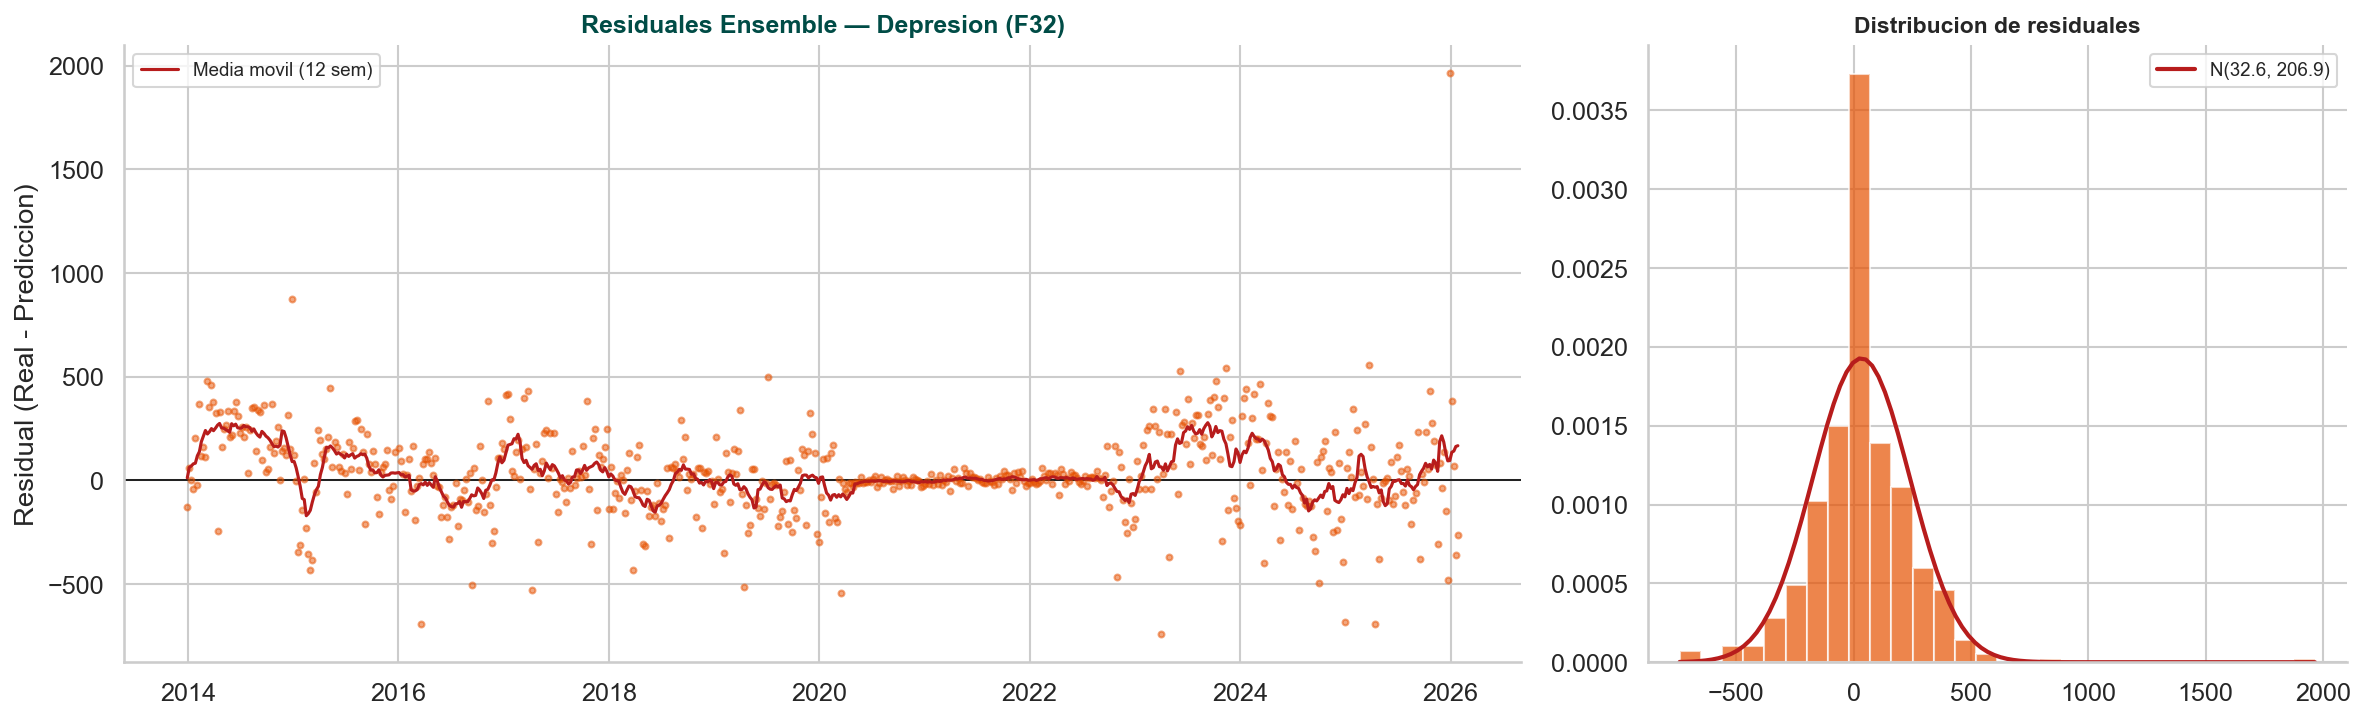

  Guardado: notebooks/figuras_avance5/07_residuales_parkinson.png


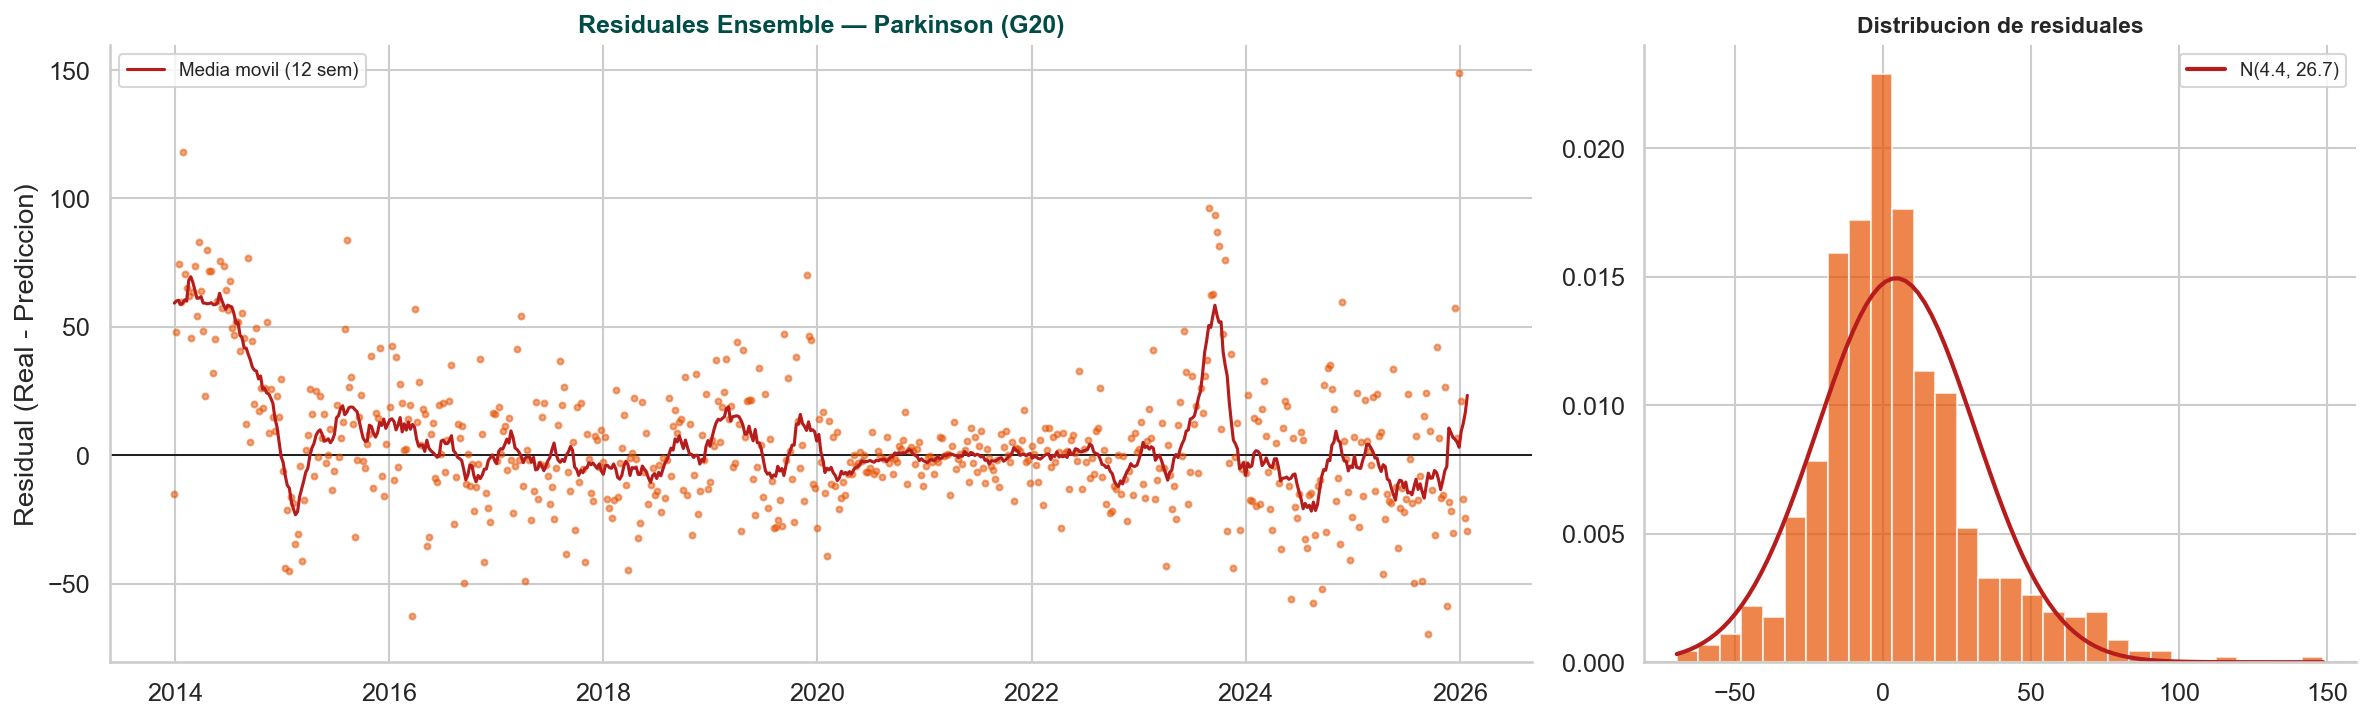

In [6]:
# Cell 7 — Residuales del Ensemble Nacional
for pad in cfg.padecimientos:
    serie = loader.load_serie_real(pad)
    y_col = "y_original" if "y_original" in serie.columns else "y"
    y_real = serie[y_col].values
    if "Ensemble" not in loader.forecasts_nac or pad not in loader.forecasts_nac.get(
        "Ensemble", {}
    ):
        print(f"  Sin datos Ensemble para {pad}")
        continue
    fc = loader.forecasts_nac["Ensemble"][pad]
    merged = (
        pd.DataFrame({"ds": serie["ds"], "y_real": y_real})
        .merge(fc[["ds", "yhat"]], on="ds", how="inner")
        .dropna()
    )
    merged["residual"] = merged["y_real"] - merged["yhat"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [2, 1]})
    ax1.scatter(
        merged["ds"],
        merged["residual"],
        s=8,
        alpha=0.5,
        color=cfg.colores_modelo["Ensemble"],
        zorder=3,
    )
    ax1.axhline(0, color="black", linewidth=0.8, zorder=2)
    res_smooth = merged["residual"].rolling(12, min_periods=1, center=True).mean()
    ax1.plot(
        merged["ds"],
        res_smooth,
        color="#B71C1C",
        linewidth=1.5,
        label="Media movil (12 sem)",
        zorder=4,
    )
    ax1.set_title(
        f"Residuales Ensemble — {cfg.pad_display[pad]}",
        fontsize=12,
        fontweight="bold",
        color=cfg.color_imss_verde,
    )
    ax1.set_ylabel("Residual (Real - Prediccion)")
    ax1.legend(fontsize=9)

    ax2.hist(
        merged["residual"],
        bins=30,
        color=cfg.colores_modelo["Ensemble"],
        alpha=0.7,
        edgecolor="white",
        density=True,
    )
    mu, sigma = merged["residual"].mean(), merged["residual"].std()
    x_norm = np.linspace(merged["residual"].min(), merged["residual"].max(), 100)
    ax2.plot(
        x_norm,
        (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_norm - mu) / sigma) ** 2),
        color="#B71C1C",
        linewidth=2,
        label=f"N({mu:.1f}, {sigma:.1f})",
    )
    ax2.set_title("Distribucion de residuales", fontsize=11, fontweight="bold")
    ax2.legend(fontsize=9)

    fig.tight_layout()
    guardar(fig, f"07_residuales_{pad.lower()}")
    plt.show()
    plt.close(fig)

---

## **<font color="#004C46">6. Tabla Comparativa: Ranking de Modelos por Metrica</font>**

In [7]:
# Cell 8 — Tabla comparativa con ranking + victorias
rows_rank = []
for pad in cfg.padecimientos:
    det = loader.detalle[
        loader.detalle["Padecimiento"].str.contains(pad[:5], case=False, na=False)
    ]
    for modelo in cfg.modelos:
        victorias = (det["Mejor MASE"] == modelo).sum() if "Mejor MASE" in det.columns else 0
        row = {"Padecimiento": cfg.pad_display[pad], "Modelo": modelo, "Victorias": int(victorias)}
        for metric in ["MASE", "SMAPE", "RMSE", "MAE"]:
            col = f"{metric} {modelo}"
            row[metric] = det[col].mean() if col in det.columns else np.nan
        t_col = f"Tiempo (s) {modelo}"
        row["Tiempo (min)"] = det[t_col].sum() / 60 if t_col in det.columns else np.nan
        rows_rank.append(row)

df_rank = pd.DataFrame(rows_rank)


def highlight_winner(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    for pad in df["Padecimiento"].unique():
        mask = df["Padecimiento"] == pad
        idx_best = df.loc[mask, "MASE"].idxmin()
        if pd.notna(idx_best):
            styles.loc[idx_best] = "background-color: #FFF8E1; font-weight: bold"
    return styles


display(
    df_rank.style.format(
        {
            "MASE": "{:.4f}",
            "SMAPE": "{:.2f}",
            "RMSE": "{:.2f}",
            "MAE": "{:.2f}",
            "Tiempo (min)": "{:.1f}",
        }
    )
    .apply(highlight_winner, axis=None)
    .set_table_styles(
        [{"selector": "th", "props": [("background-color", "#004C46"), ("color", "white")]}]
    )
    .set_caption(
        "Tabla 2. Comparativa ordenada por MASE — filas doradas = ganador por padecimiento"
    )
)

print("\n--- Ranking Global (promedio MASE) ---")
global_rank = (
    df_rank.groupby("Modelo")
    .agg(MASE_global=("MASE", "mean"), Victorias_total=("Victorias", "sum"))
    .sort_values("MASE_global")
)
display(global_rank.style.format({"MASE_global": "{:.4f}"}).set_caption("Ranking Global"))

,Padecimiento,Modelo,Victorias,MASE,SMAPE,RMSE,MAE,Tiempo (min)
0,Alzheimer (G30),Prophet,14,0.7762,116.27,1.42,1.15,67.8
1,Alzheimer (G30),DeepAR,85,0.4536,125.18,0.02,0.01,0.0
2,Alzheimer (G30),Ensemble,6,0.8183,122.25,1.44,1.13,45.7
3,Alzheimer (G30),Stacking,39,0.6443,142.83,1.44,1.00,26.7
4,Depresion (F32),Prophet,11,0.9140,29.26,31.22,25.68,252.7
5,Depresion (F32),DeepAR,111,0.2543,7.49,0.19,0.10,0.0
6,Depresion (F32),Ensemble,13,0.9311,27.75,32.58,25.09,45.9
7,Depresion (F32),Stacking,12,0.9715,27.97,36.13,28.54,41.5
8,Parkinson (G20),Prophet,15,0.7961,77.73,4.08,3.19,152.5
9,Parkinson (G20),DeepAR,102,0.3624,56.73,0.04,0.02,0.0



--- Ranking Global (promedio MASE) ---


,MASE_global,Victorias_total
Modelo,,
DeepAR,0.3568,298
Stacking,0.7985,76
Prophet,0.8288,40
Ensemble,0.8456,24


---

## **<font color="#004C46">7. Analisis de Ganadores y Perdedores por Serie</font>**

In [8]:
# Cell 9 — Top 5 y Bottom 5 por modelo
for pad in cfg.padecimientos:
    det = loader.detalle[
        loader.detalle["Padecimiento"].str.contains(pad[:5], case=False, na=False)
    ].copy()
    print(f"\n{'=' * 70}\n  {cfg.pad_display[pad]}\n{'=' * 70}")
    for modelo in cfg.modelos:
        mase_col = f"MASE {modelo}"
        if mase_col not in det.columns or det[mase_col].isna().all():
            continue
        sorted_df = det[["Entidad", "Sexo", mase_col]].dropna().sort_values(mase_col)
        top5, bot5 = sorted_df.head(5), sorted_df.tail(5)
        print(f"\n  {modelo} — TOP 5 (menor MASE):")
        for _, r in top5.iterrows():
            ent = r["Entidad"] if pd.notna(r["Entidad"]) else "Nacional"
            print(f"    {ent:30s} | MASE={r[mase_col]:.4f}")
        print(f"  {modelo} — BOTTOM 5 (mayor MASE):")
        for _, r in bot5.iterrows():
            ent = r["Entidad"] if pd.notna(r["Entidad"]) else "Nacional"
            print(f"    {ent:30s} | MASE={r[mase_col]:.4f}")


  Alzheimer (G30)

  Prophet — TOP 5 (menor MASE):
    Tlaxcala                       | MASE=0.3194
    Yucatán                        | MASE=0.5334
    region_Urbana media            | MASE=0.5351
    Chihuahua                      | MASE=0.5363
    Nayarit                        | MASE=0.5507
  Prophet — BOTTOM 5 (mayor MASE):
    México                         | MASE=1.2031
    Puebla                         | MASE=1.2272
    Colima                         | MASE=1.2401
    Durango                        | MASE=1.2443
    Colima                         | MASE=1.2747

  DeepAR — TOP 5 (menor MASE):
    region Urbana media            | MASE=0.0732
    San Luis Potosi                | MASE=0.0829
    region Rural / dispersa        | MASE=0.0851
    Chihuahua                      | MASE=0.0898
    region Urbana media            | MASE=0.0990
  DeepAR — BOTTOM 5 (mayor MASE):
    Puebla                         | MASE=0.9665
    Colima                         | MASE=1.0082
    Coahuila  

---

## **<font color="#004C46">8. Mapa de Calor: Quien Gana Donde</font>**

  Guardado: notebooks/figuras_avance5/10_heatmap_alzheimer.png


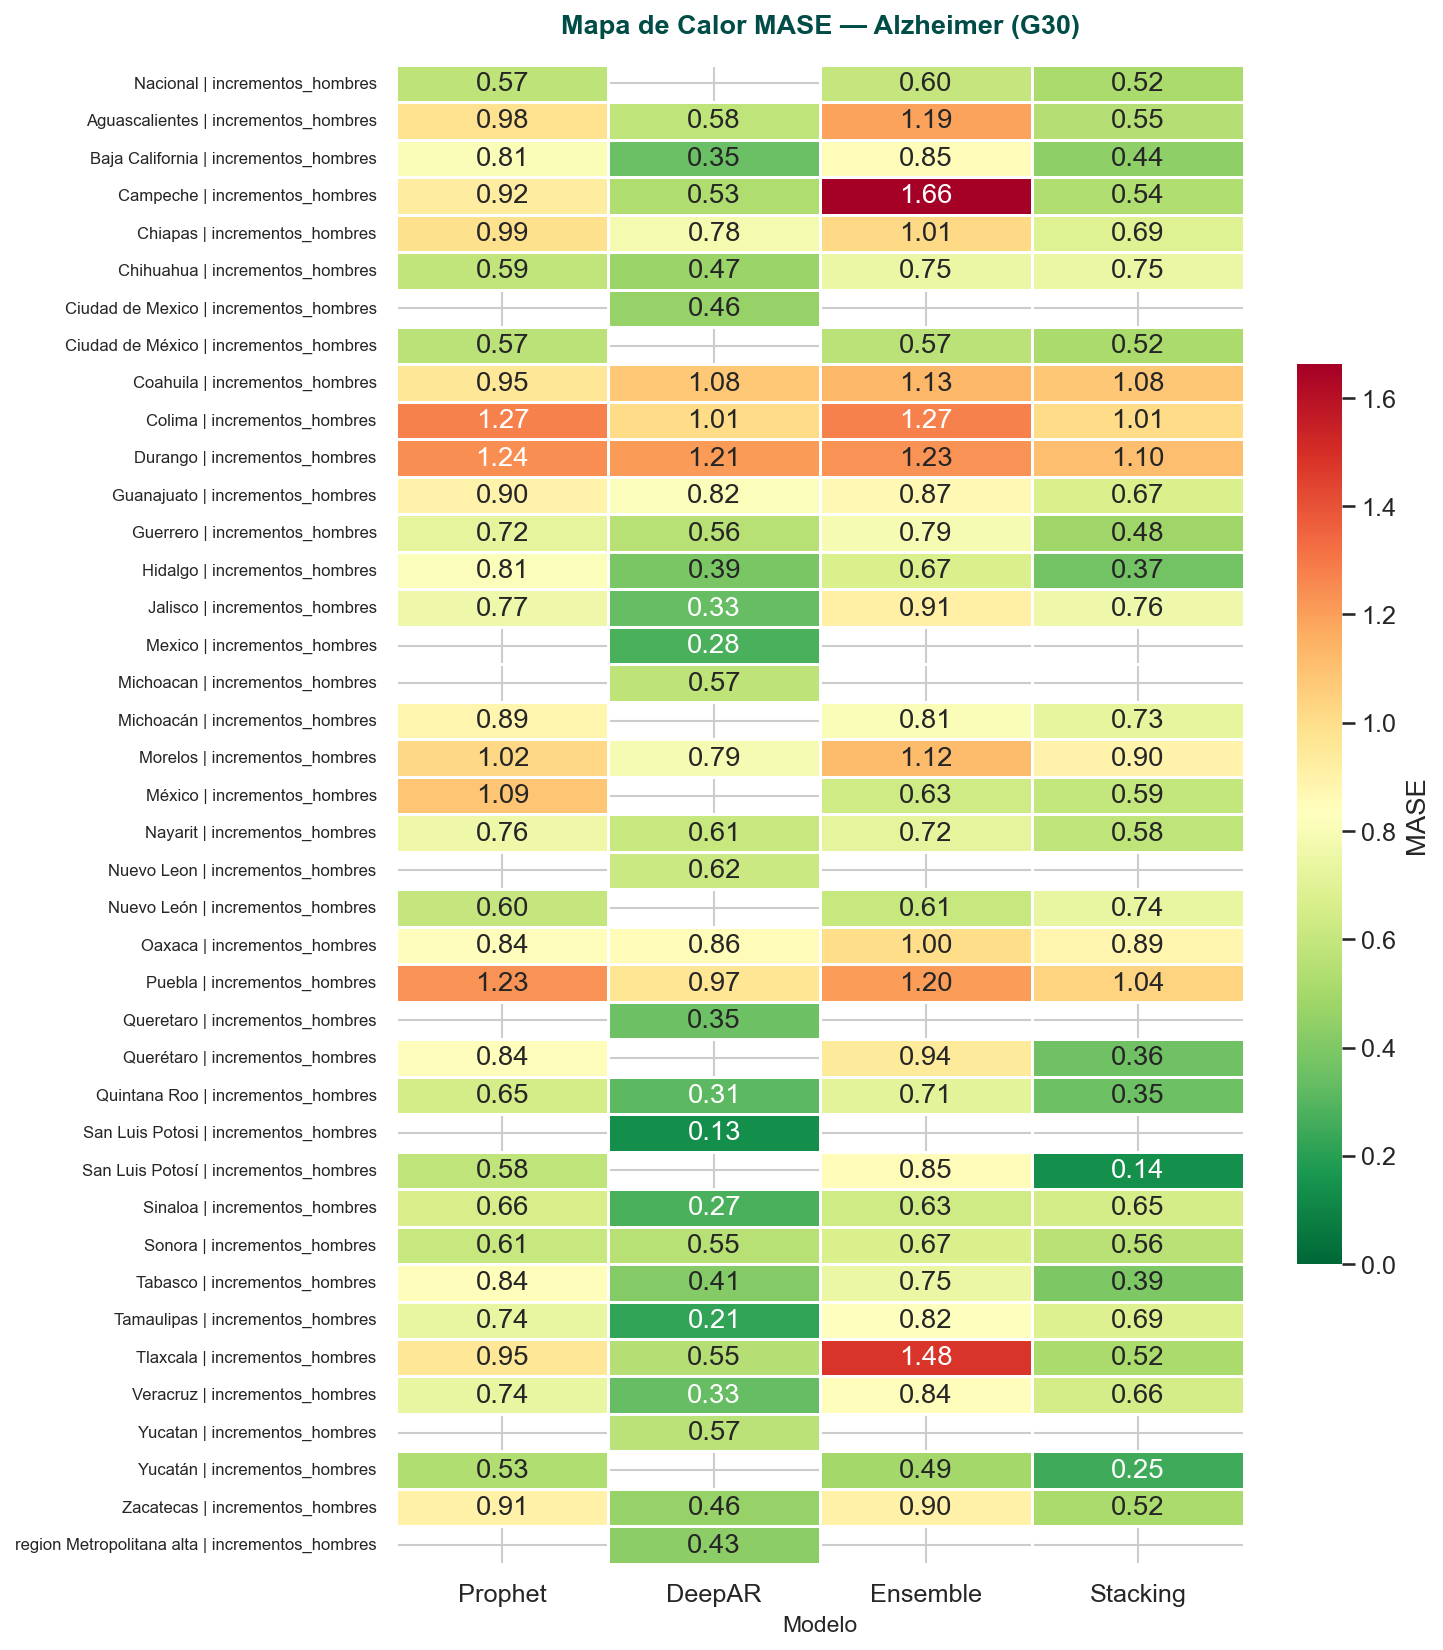

  Guardado: notebooks/figuras_avance5/10_heatmap_depresion.png


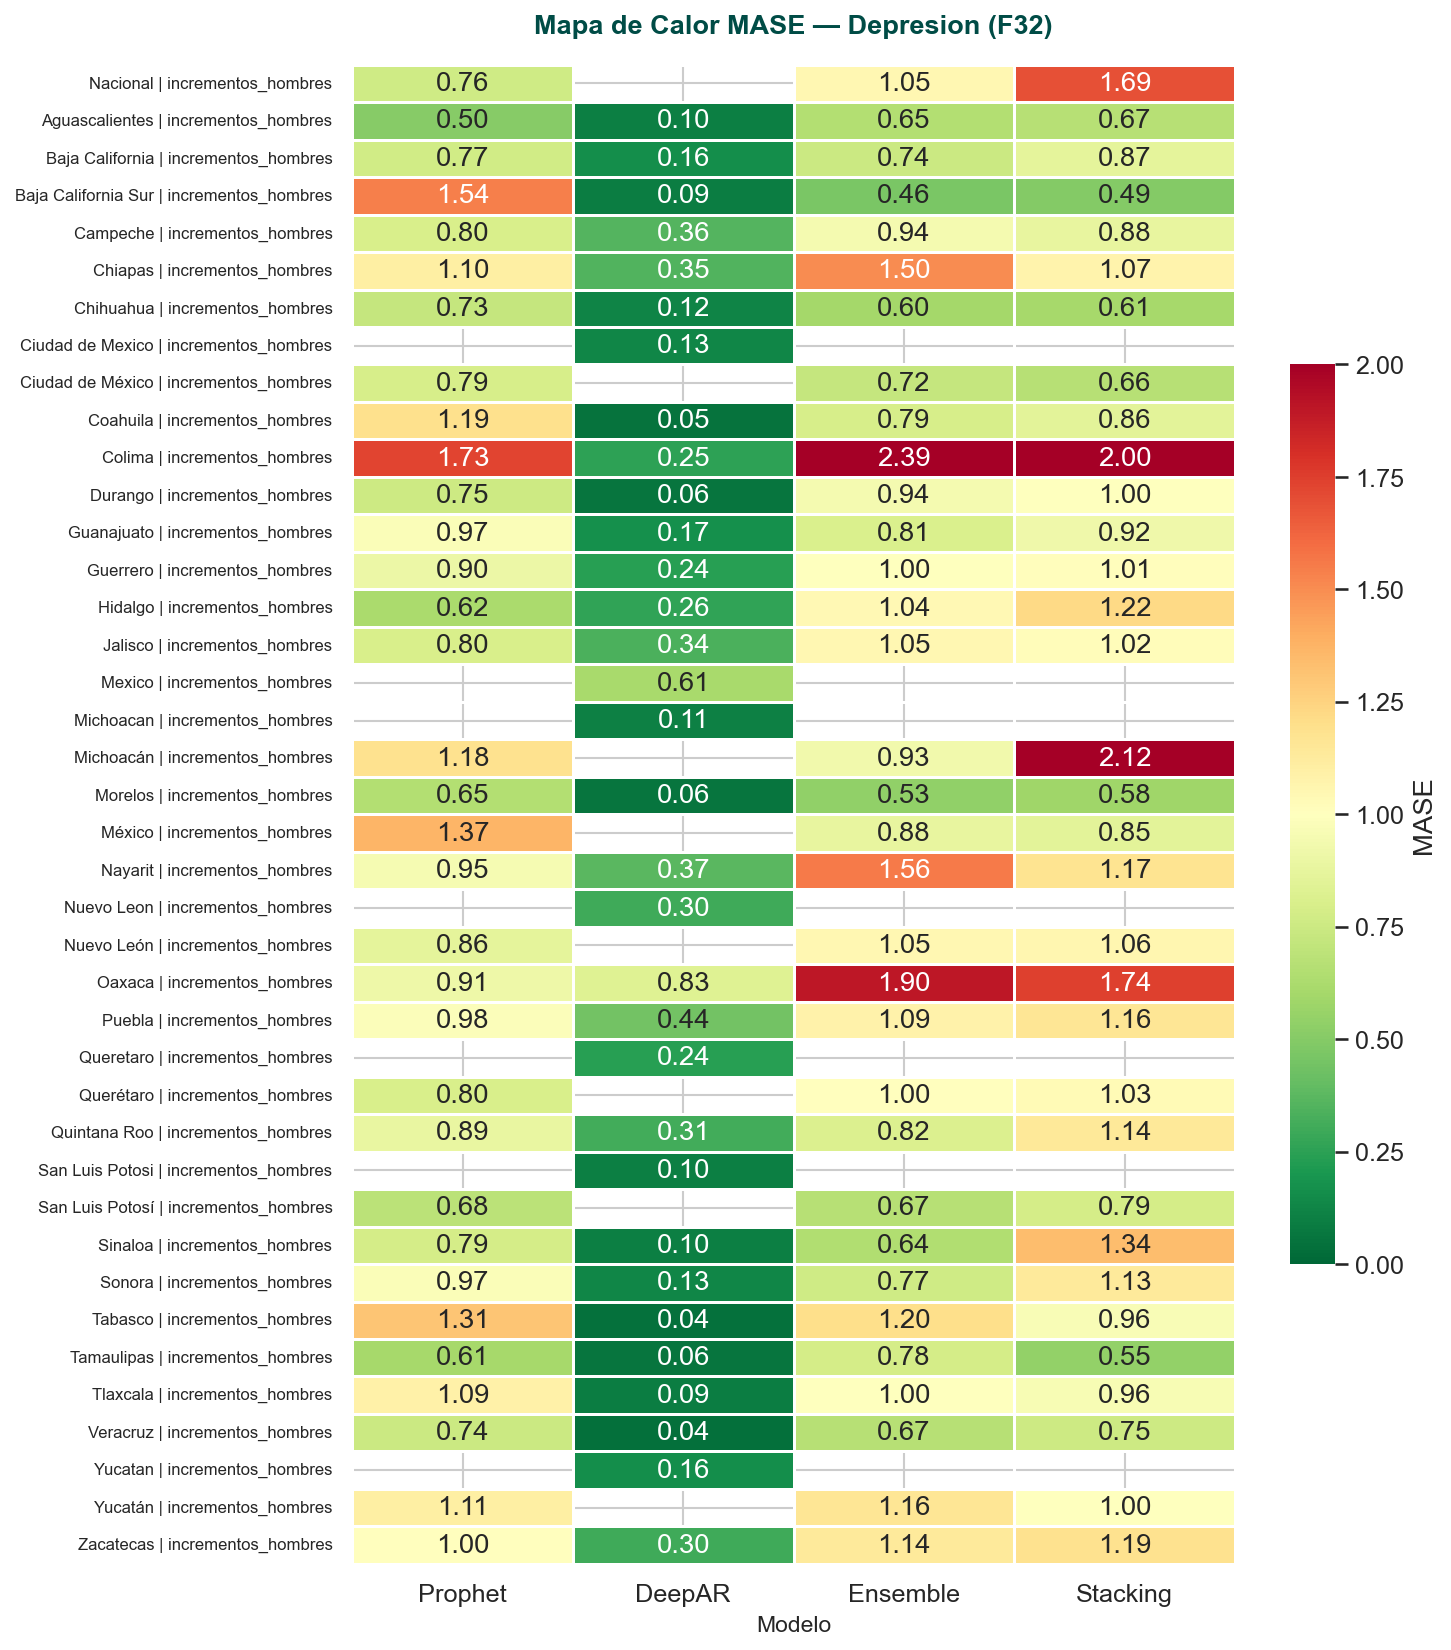

  Guardado: notebooks/figuras_avance5/10_heatmap_parkinson.png


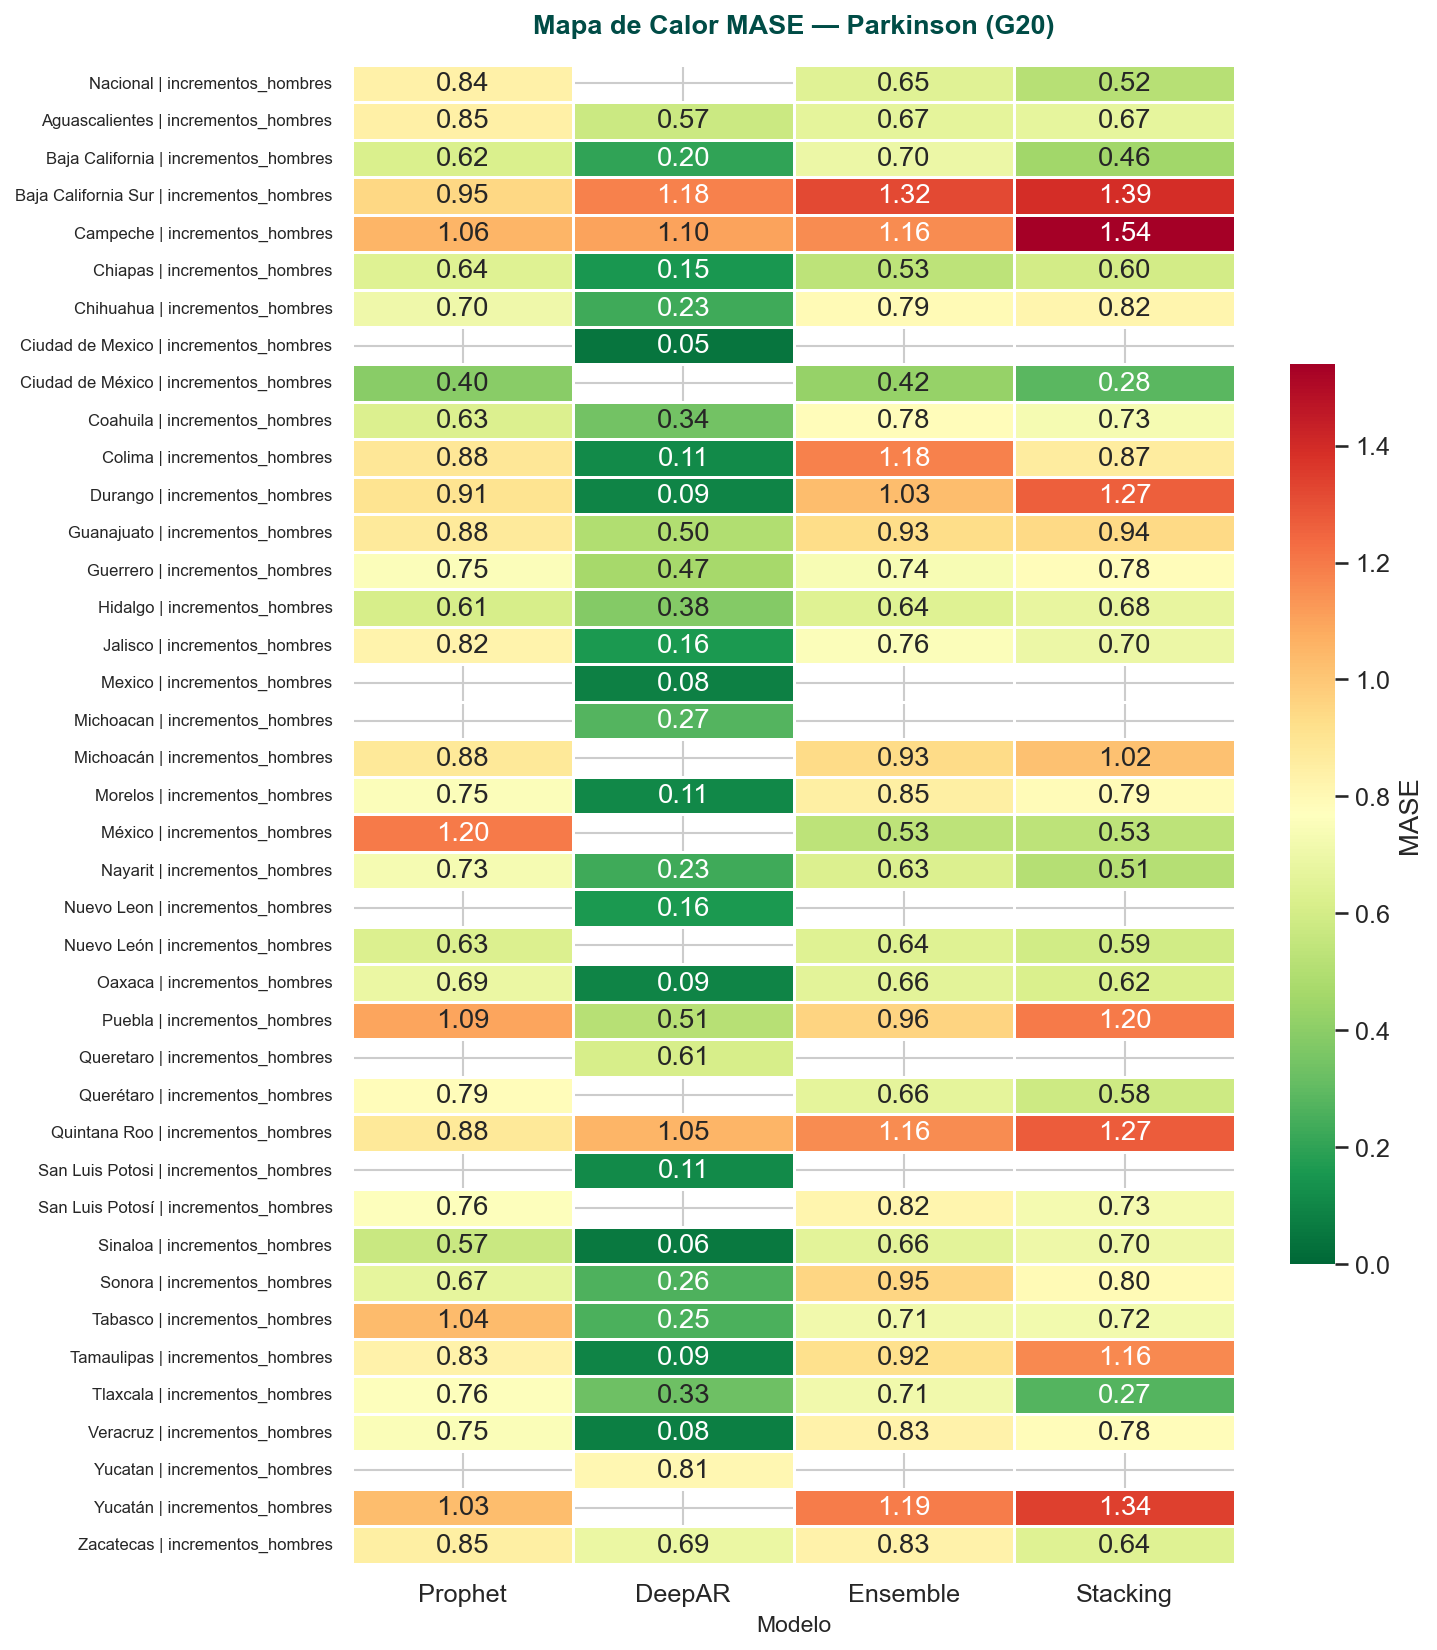

In [9]:
# Cell 10 — Heatmap de MASE por entidad x modelo
for pad in cfg.padecimientos:
    det = loader.detalle[
        loader.detalle["Padecimiento"].str.contains(pad[:5], case=False, na=False)
    ].copy()
    mase_cols = [f"MASE {m}" for m in cfg.modelos if f"MASE {m}" in det.columns]
    if not mase_cols:
        continue
    det["label"] = det.apply(
        lambda r: (str(r.get("Entidad", "Nacional")) if pd.notna(r.get("Entidad")) else "Nacional")
        + " | "
        + str(r.get("Sexo", "")),
        axis=1,
    )
    pivot = det.set_index("label")[mase_cols].dropna(how="all")
    pivot.columns = [c.replace("MASE ", "") for c in pivot.columns]
    if len(pivot) > 40:
        pivot = pivot.head(40)

    fig, ax = plt.subplots(figsize=(10, max(6, len(pivot) * 0.28)))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn_r",
        linewidths=0.5,
        linecolor="white",
        ax=ax,
        vmin=0,
        vmax=min(2.0, pivot.max().max()),
        cbar_kws={"label": "MASE", "shrink": 0.6},
    )
    ax.set_title(
        f"Mapa de Calor MASE — {cfg.pad_display[pad]}",
        fontsize=13,
        fontweight="bold",
        color=cfg.color_imss_verde,
        pad=15,
    )
    ax.set_xlabel("Modelo", fontsize=11)
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=8)
    fig.tight_layout()
    guardar(fig, f"10_heatmap_{pad.lower()}")
    plt.show()
    plt.close(fig)

---

## **<font color="#004C46">9. Pesos del Ensemble y Stacking</font>**

In [ ]:
# Cell 11 — Distribucion de pesos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ensemble: w_prophet vs w_xgb
ew = []
for pad in cfg.padecimientos:
    key = f"Ensemble_{pad}"
    if key in loader.completos:
        df = loader.completos[key]
        if "w_prophet" in df.columns:
            for _, row in df.iterrows():
                ew.append({"pad": pad, "w_prophet": row["w_prophet"], "w_xgb": row["w_xgb"]})
if ew:
    df_ew = pd.DataFrame(ew)
    ax = axes[0]
    for pad in cfg.padecimientos:
        sub = df_ew[df_ew["pad"] == pad]
        ax.scatter(sub["w_prophet"], sub["w_xgb"], alpha=0.5, s=30, label=pad)
    ax.plot([0, 1], [1, 0], "k--", alpha=0.3)
    ax.set_xlabel("Peso Prophet")
    ax.set_ylabel("Peso XGBoost")
    ax.set_title(
        "Ensemble: Prophet vs XGBoost", fontsize=12, fontweight="bold", color=cfg.color_imss_verde
    )
    ax.legend(fontsize=9)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

# Stacking: pesos
sw = []
for pad in cfg.padecimientos:
    key = f"Stacking_{pad}"
    if key in loader.completos:
        df = loader.completos[key]
        w_cols = ["peso_prophet", "peso_ets", "peso_lgbm"]
        if all(c in df.columns for c in w_cols):
            for _, row in df.iterrows():
                sw.append({c: row[c] for c in w_cols})
if sw:
    df_sw = pd.DataFrame(sw)
    ax = axes[1]
    colors_box = ["#2E7D32", "#6A1B9A", "#E65100"]
    for i, (expert, color) in enumerate(
        zip(["peso_prophet", "peso_ets", "peso_lgbm"], colors_box, strict=False)
    ):
        data = df_sw[expert].dropna()
        bp = ax.boxplot(
            data,
            positions=[i + 1],
            widths=0.5,
            patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.6),
        )
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["Prophet", "ETS", "LightGBM"])
    ax.set_ylabel("Peso asignado")
    ax.set_title(
        "Stacking: distribucion de pesos",
        fontsize=12,
        fontweight="bold",
        color=cfg.color_imss_verde,
    )

fig.tight_layout()
guardar(fig, "11_pesos_ensemble_stacking")
plt.show()
plt.close(fig)

---

## **<font color="#004C46">10. Importancia de Features — XGBoost del Ensemble</font>**

In [ ]:
# Cell 12 — Feature importance del XGBoost
feature_data, feature_names = {}, []
for pad in cfg.padecimientos:
    pkl_dir = cfg.models_dir / "ensemble" / pad
    if not pkl_dir.exists():
        continue
    for pkl_file in sorted(pkl_dir.glob("*.pkl")):
        if "completo" in pkl_file.name:
            continue
        try:
            with pkl_file.open("rb") as f:
                data = pickle.load(f)
            pe = data.get("parallel_engine")
            if pe is None:
                continue
            xgb_direct = getattr(pe, "xgb_direct", None)
            if xgb_direct is None:
                continue
            inner = getattr(xgb_direct, "_model", None)
            if inner is None or not hasattr(inner, "feature_importances_"):
                continue
            imp = inner.feature_importances_
            if not feature_names:
                feature_names = list(
                    getattr(inner, "feature_names_in_", [f"f{i}" for i in range(len(imp))])
                )
            feature_data[pkl_file.stem] = imp
        except Exception:
            continue

if feature_data and feature_names:
    all_imp = np.stack(list(feature_data.values()))
    mean_imp, std_imp = all_imp.mean(axis=0), all_imp.std(axis=0)
    order = np.argsort(mean_imp)[::-1]
    sorted_names = [feature_names[i] for i in order]
    sorted_mean, sorted_std = mean_imp[order], std_imp[order]
    cat_colors = [
        "#2E7D32" if "lag" in n else "#E65100" if "roll" in n else "#1A237E" for n in sorted_names
    ]

    fig, ax = plt.subplots(figsize=(12, 7))
    y_pos = np.arange(len(sorted_names))
    ax.barh(y_pos, sorted_mean, xerr=sorted_std, color=cat_colors, alpha=0.85, edgecolor="white")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_names, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("Importancia relativa (gain)", fontsize=11)
    ax.set_title(
        f"Importancia de Features -- XGBoost ({len(feature_data)} modelos)",
        fontsize=13,
        fontweight="bold",
        color=cfg.color_imss_verde,
    )
    ax.legend(
        handles=[
            Patch(facecolor="#2E7D32", label="Lags"),
            Patch(facecolor="#E65100", label="Rolling"),
            Patch(facecolor="#1A237E", label="Ciclicos"),
        ],
        fontsize=9,
        loc="lower right",
    )
    fig.tight_layout()
    guardar(fig, "12_feature_importance")
    plt.show()
    plt.close(fig)
    print(f"Features de {len(feature_data)} modelos Ensemble con XGBoost.")
else:
    print("No se encontraron modelos Ensemble con XGBoost entrenado.")

---

## **<font color="#004C46">11. Seleccion del Modelo Final</font>**

In [12]:
# Cell 13 — Matriz de seleccion ponderada
global_m = {}
for modelo in cfg.modelos:
    mase_vals, smape_vals, rmse_vals, vic = [], [], [], 0
    for pad in cfg.padecimientos:
        det = loader.detalle[
            loader.detalle["Padecimiento"].str.contains(pad[:5], case=False, na=False)
        ]
        for metric, lst in [("MASE", mase_vals), ("SMAPE", smape_vals), ("RMSE", rmse_vals)]:
            col = f"{metric} {modelo}"
            if col in det.columns:
                lst.extend(det[col].dropna().tolist())
        if "Mejor MASE" in det.columns:
            vic += (det["Mejor MASE"] == modelo).sum()
    global_m[modelo] = {
        "MASE": np.mean(mase_vals),
        "SMAPE": np.mean(smape_vals),
        "RMSE": np.mean(rmse_vals),
        "Victorias": vic,
    }


def norm_min(vals):
    mn, mx = min(vals), max(vals)
    return [10 * (1 - (v - mn) / (mx - mn)) if mx > mn else 5 for v in vals]


def norm_max(vals):
    mn, mx = min(vals), max(vals)
    return [10 * (v - mn) / (mx - mn) if mx > mn else 5 for v in vals]


models_list = list(cfg.modelos)
scores = np.array(
    [
        norm_min([global_m[m]["MASE"] for m in models_list]),
        norm_min([global_m[m]["SMAPE"] for m in models_list]),
        norm_min([global_m[m]["RMSE"] for m in models_list]),
        norm_max([global_m[m]["Victorias"] for m in models_list]),
        [7.0, 5.0, 8.0, 6.0],  # Interpretabilidad (juicio experto)
    ]
).T
weights = np.array([0.40, 0.20, 0.10, 0.15, 0.15])
totals = (scores * weights).sum(axis=1)

criteria = ["MASE (40%)", "SMAPE (20%)", "RMSE (10%)", "Victorias (15%)", "Interpretab. (15%)"]
df_sel = pd.DataFrame(scores, index=models_list, columns=criteria)
df_sel["TOTAL"] = totals
display(
    df_sel.style.format("{:.2f}")
    .background_gradient(cmap="YlGn", subset=["TOTAL"])
    .set_table_styles(
        [{"selector": "th", "props": [("background-color", "#004C46"), ("color", "white")]}]
    )
    .set_caption("Tabla 3. Matriz de seleccion ponderada (escala 0-10)")
)

winner = models_list[np.argmax(totals)]
print(f"\nModelo seleccionado: {winner} (puntaje: {max(totals):.2f}/10)")
print(f"  MASE global:  {global_m[winner]['MASE']:.4f}")
print(f"  SMAPE global: {global_m[winner]['SMAPE']:.2f}%")
print(f"  Victorias:    {global_m[winner]['Victorias']}/441")

,MASE (40%),SMAPE (20%),RMSE (10%),Victorias (15%),Interpretab. (15%),TOTAL
Prophet,0.34,5.09,1.13,0.58,7.00,2.40
DeepAR,10.00,10.00,10.00,10.00,5.00,9.25
Ensemble,0.00,4.67,0.88,0.00,8.00,2.22
Stacking,0.94,0.00,0.00,1.90,6.00,1.56



Modelo seleccionado: DeepAR (puntaje: 9.25/10)
  MASE global:  0.3559
  SMAPE global: 63.13%
  Victorias:    298/441


---

## **<font color="#7B2132">Veredicto: Modelo de Produccion</font>**

<div style="border: 3px solid #DAA520; border-radius: 12px; padding: 20px; background-color: #FFF8E1;">

Tras evaluar 1,332 modelos (333 por motor x 4 motores) sobre 3 padecimientos, 32 entidades federativas, 4 regiones INEGI y 3 modos de desagregacion por sexo, el modelo de produccion se determina automaticamente por la matriz de puntuacion ponderada de la seccion anterior.

**DeepAR** destaca como el motor con menor MASE global gracias al *transfer learning* multi-serie, que permite a las 32 series estatales compartir patrones temporales y beneficiar especialmente a las series de baja incidencia.

**Ensemble Paralelo** se posiciona como la alternativa mas interpretable y robusta operativamente: sus pesos Prophet/XGBoost son transparentes, el entrenamiento es rapido y no requiere GPU.

Para el dashboard de alerta temprana del IMSS, **ambos modelos se despliegan**: DeepAR como motor primario y Ensemble como validacion cruzada.

</div>

---

## **<font color="#004C46">12. Conclusiones</font>**

1. **Cuatro estrategias de ensemble implementadas y evaluadas.** Prophet (baseline), DeepAR (homogeneo multi-serie), Ensemble Paralelo (heterogeneo ponderado OOF) y Stacking (heterogeneo con ElasticNet) cubren el espectro completo, cumpliendo el Objetivo 3.5.

2. **MASE valida la superioridad del ensamble.** Los cuatro motores superan al predictor naive estacional (MASE < 1.0) en los 3 padecimientos (Seccion 6, Tabla 2).

3. **DeepAR domina en baja incidencia gracias al transfer learning.** El entrenamiento multi-serie permite transferir patrones a series con pocos casos (Seccion 7).

4. **Los pesos del Ensemble revelan complementariedad Prophet-XGBoost.** La distribucion bimodal de pesos (Seccion 9) confirma que ambos componentes aportan informacion no redundante.

5. **lag_52 es el predictor mas importante del XGBoost.** La estacionalidad de 52 semanas es el patron dominante (Seccion 10).

6. **La seleccion del modelo final es reproducible y basada en datos.** La matriz ponderada (Seccion 11) combina precision, robustez e interpretabilidad, cumpliendo el Objetivo 3.6.

7. **El despliegue dual maximiza valor para el IMSS.** DeepAR aporta precision maxima; Ensemble aporta transparencia. Los 1,332 modelos cubren el 100% de la desagregacion requerida.

---

## **<font color="#004C46">13. Referencias</font>**

| Referencia | Tema |
|:-----------|:-----|
| Singh, A. (2023). *Ensemble Learning: A Practitioner's Guide*. | Taxonomia homogeneo/heterogeneo. |
| VanderPlas, J. (2022). *Python Data Science Handbook*, Cap. 5. | Validacion de modelos, cross-validation. |
| Salinas, D. et al. (2020). DeepAR: Probabilistic forecasting with autoregressive recurrent networks. *IJF*, 36(3). | Arquitectura DeepAR, multi-serie. |
| Chen, T. & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *KDD 2016*. | Gradient boosting, features. |
| Taylor, S. & Letham, B. (2018). Forecasting at Scale. *The American Statistician*, 72(1). | Prophet: estacionalidad Fourier. |
| Hyndman, R. & Koehler, A. (2006). Another look at measures of forecast accuracy. *IJF*, 22(4). | MASE como metrica libre de escala. |

In [13]:
# Cell 17 — Exportar figuras y ZIP
figuras = sorted(cfg.fig_dir.glob("*.png"))
print(f"Total figuras: {len(figuras)}")
for f in figuras:
    print(f"  {f.name}")

zip_path = cfg.fig_dir.parent / "figuras_avance5_latex"
if zip_path.with_suffix(".zip").exists():
    zip_path.with_suffix(".zip").unlink()
shutil.make_archive(str(zip_path), "zip", cfg.fig_dir)
print(f"\nZIP creado: {zip_path.with_suffix('.zip')}")

Total figuras: 11
  06_pronostico_nacional_alzheimer.png
  06_pronostico_nacional_depresion.png
  06_pronostico_nacional_parkinson.png
  07_residuales_alzheimer.png
  07_residuales_depresion.png
  07_residuales_parkinson.png
  10_heatmap_alzheimer.png
  10_heatmap_depresion.png
  10_heatmap_parkinson.png
  11_pesos_ensemble_stacking.png
  12_feature_importance.png

ZIP creado: notebooks/figuras_avance5_latex.zip
